In [1]:
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from PIL import Image
from sklearn.model_selection import train_test_split

from config import SEED

In [2]:
def load_image_dataset(img_dir, target_size=None):
    df = pd.read_csv(os.path.join(img_dir, 'labels.csv'))
    X, y = [], []
    for _, row in df.iterrows():
        path = os.path.join(img_dir, row['filename'])
        img = Image.open(path)
        
        if target_size:
            img = img.resize(target_size, Image.BICUBIC)
        
        img = np.array(img)

        X.append(img)
        y.append(row['label'])

    return np.array(X), np.array(y)

# Entrenamiento de MobileNet

Elegimos el dataset

In [ ]:
dataset = 'ventanas/crudos_cuadrados'

## Imágenes

Cargamos las imagenes desde el path del dataset elegido.

El tamaño de las imágenes es:
+ Para ciclos respiratorios: `target_size=(N_MELS, MAX_LENGTH)`
+ Para ventanas temporales: `target_size=(N_MELS, WINDOW_LENGTH)`
> Para las ventanas cuadradas se usó ``target_size=(224, 224)``, pero es una excepción.

In [ ]:
train_dir = f'./data_procesada/{dataset}/imgs/train'
val_dir = f'./data_procesada/{dataset}/imgs/val'
test_dir = f'./data_procesada/{dataset}/imgs/test'

In [5]:
X_train, y_train = load_image_dataset(train_dir, target_size=(224, 224))
X_val, y_val = load_image_dataset(val_dir, target_size=(224, 224))
X_test, y_test = load_image_dataset(test_dir, target_size=(224, 224))

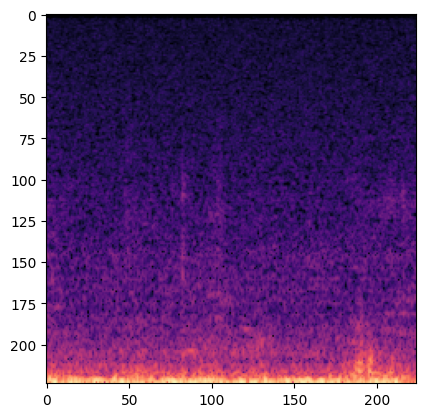

In [6]:
plt.imshow(X_train[2]);

### Definición del modelo

+ Se usa MobileNet como modelo base, con pesos preentrenados.
+ Se agregan un par de capas de augmentation.
+ Una capa de normalización como lo indica el tutorial de MobileNet.
+ Luego unas capas propias sobre el modelo base.
+ Finalmente, una capa con output binario.

In [7]:
base_model = keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(224, 224, 3),
    weights="imagenet"
)

base_model.trainable = False # freezeo el modelo base

inputs = keras.Input(shape=(224, 224, 3))
traslation_layer = keras.layers.RandomTranslation(height_factor=0, width_factor=0.2, seed=SEED) # augmentacion
flip_layer = keras.layers.RandomFlip("horizontal", seed=SEED) # augmentacion
scale_layer = keras.layers.Rescaling(scale=1 / 127.5, offset=-1) # normalizacion

x = flip_layer(inputs) # augmentacion
x = traslation_layer(x) # augmentacion
x = scale_layer(x) # normalizacion
x = base_model(x, training=False) # inferencia
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

In [8]:
model.summary(show_trainable=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip (RandomFlip)    │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_translation          │ (None, 224, 224, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 7, 7, 1280)    │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,602,433 (9.93 MB)

 Trainable params: 344,449 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Ajuste

Definimos:
+ Learning rate (opcional).
+ Función de perdida: ``BinaryCrossentropy``.
+ Métricas auxiliares: `AUC-ROC` y `Recall`.
+ Early stopping: `patience=5`, `monitor='val_loss`, `min_delta=0.001`.

Entrenamos con un ``batch_size`` relativamente pequeño y con una cantidad de ``epochs`` alta para que se active el early stopping.

In [9]:
# lr_schedule = keras.optimizers.schedules.PolynomialDecay(
#     initial_learning_rate=1e-3,
#     decay_steps=3000,
#     end_learning_rate=1e-7,
#     power=1.0)

model.compile(
    optimizer=keras.optimizers.Adam(), #learning_rate=lr_schedule),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()]
)

In [10]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [11]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 108s 959ms/step - auc: 0.5414 - loss: 0.7122 - recall: 0.5680 - val_auc: 0.6549 - val_loss: 0.6765 - val_recall: 0.3908
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 91s 907ms/step - auc: 0.5796 - loss: 0.6829 - recall: 0.6141 - val_auc: 0.6699 - val_loss: 0.6671 - val_recall: 0.3131
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 142s 911ms/step - auc: 0.6233 - loss: 0.6667 - recall: 0.6408 - val_auc: 0.6709 - val_loss: 0.6612 - val_recall: 0.4199
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 91s 913ms/step - auc: 0.6418 - loss: 0.6601 - recall: 0.6754 - val_auc: 0.6904 - val_loss: 0.6475 - val_recall: 0.8738
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 89s 895ms/step - auc: 0.6567 - loss: 0.6503 - recall: 0.7039 - val_auc: 0.7011 - val_loss: 0.6356 - val_recall: 0.5777
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 90s 903ms/step - auc: 0.6810 - loss: 0.6445 - recall: 0.7136 - val_auc: 0.7120 - val_loss: 0.6566 - val_recall: 0.4126
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 93s 

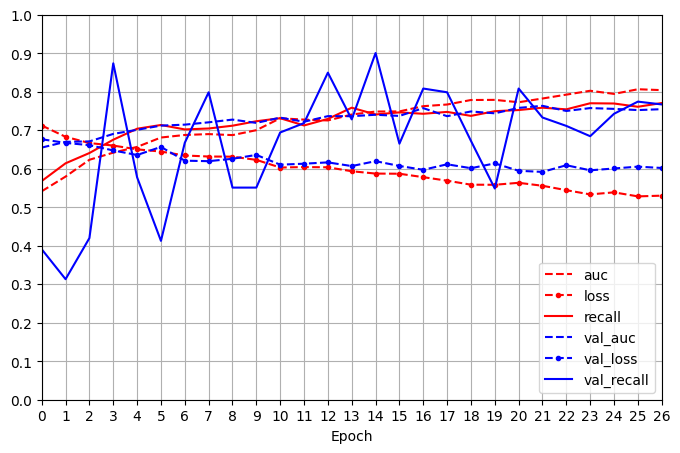

In [12]:
pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 26], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "r-", "b--","b--.", "b-"], xticks=range(0, 27), yticks=np.arange(0, 1.1, 0.1))
plt.show()

### Evaluación rápida

In [13]:
model.evaluate(X_test, y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 478ms/step - auc: 0.7326 - loss: 0.6166 - recall: 0.7282


[0.6166155338287354, 0.7325804233551025, 0.7281553149223328]

Finalmente, guardamos el modelo para evaluación posterior

In [ ]:
os.makedirs(f'./neural_network/modelos/{dataset}', exist_ok=True)

model.save(f'./neural_network/modelos/{dataset}/melspec.keras')

## Arrays

Cargamos los datos considerando el tamaño del espectrograma (igual que antes).

In [ ]:
train_data = np.load(f'./data_procesada/{dataset}/train_melspectrogram.npz')
X_train = train_data['X']
y_train = train_data['y']

test_data = np.load(f'./data_procesada/{dataset}/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED
)

Al ser una matriz de un espectrograma tiene un solo canal (en lugar de 3, RGB).

In [18]:
X_train = X_train.reshape(-1, 224, 224, 1)
X_val = X_val.reshape(-1, 224, 224, 1)
X_test = X_test.reshape(-1, 224, 224, 1)

Repetimos ese canal 3 veces para poder usar MobileNet

In [19]:
X_train = np.repeat(X_train, 3, axis=-1)
X_val = np.repeat(X_val, 3, axis=-1)
X_test = np.repeat(X_test, 3, axis=-1)

Mismo modelo

In [20]:
base_model = keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(224, 224, 3),
    weights="imagenet"
)
base_model.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
translation_layer = keras.layers.RandomTranslation(height_factor=0, width_factor=0.2, seed=SEED)
flip_layer = keras.layers.RandomFlip("horizontal", seed=SEED)
scale_layer = keras.layers.Rescaling(scale=2/80, offset=1)

x = flip_layer(inputs)
x = translation_layer(x)
x = scale_layer(x)
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)

model_melspec = keras.Model(inputs, outputs)

In [21]:
model_melspec.summary(show_trainable=True)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_3 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip_1 (RandomFlip)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_translation_1        │ (None, 224, 224, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling_1 (Rescaling)     │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 7, 7, 1280)    │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_1  │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_2 (Dropout)         │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_4 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_3 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_5 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,602,433 (9.93 MB)

 Trainable params: 344,449 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
model_melspec.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()]
)

In [23]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [24]:
history_melspec = model_melspec.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 98s 927ms/step - auc_1: 0.5431 - loss: 0.7115 - recall_1: 0.5890 - val_auc_1: 0.6390 - val_loss: 0.6952 - val_recall_1: 0.1318
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 132s 821ms/step - auc_1: 0.5799 - loss: 0.6873 - recall_1: 0.5749 - val_auc_1: 0.6292 - val_loss: 0.6738 - val_recall_1: 0.5835
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 75s 754ms/step - auc_1: 0.6123 - loss: 0.6745 - recall_1: 0.6599 - val_auc_1: 0.6950 - val_loss: 0.6626 - val_recall_1: 0.9529
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 77s 766ms/step - auc_1: 0.6310 - loss: 0.6655 - recall_1: 0.6606 - val_auc_1: 0.6785 - val_loss: 0.6679 - val_recall_1: 0.2894
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 86s 856ms/step - auc_1: 0.6531 - loss: 0.6541 - recall_1: 0.6771 - val_auc_1: 0.7164 - val_loss: 0.6398 - val_recall_1: 0.4447
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 87s 872ms/step - auc_1: 0.6712 - loss: 0.6474 - recall_1: 0.6440 - val_auc_1: 0.7245 - val_loss: 0.6280 - val_recall_1: 0.82

In [25]:
model_melspec.evaluate(X_test, y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 517ms/step - auc_1: 0.7601 - loss: 0.5811 - recall_1: 0.7515


[0.5810979008674622, 0.7601139545440674, 0.7514563202857971]

In [ ]:
model_melspec.save(f'./neural_network/modelos/{dataset}/melspec.keras')